# Lesson 1: Introduction to optimization projects

# Traveling Salesman Problem (Euclidean)

This notebook will go over the following subjects:
- Generation of an euclidean TSP
- Exact resolution of the problem
- Closest Neighbour solution of the algorithm

The following libraries will be used:
- numpy
- matplotlib
- random
- itertools

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import random as rm
from itertools import permutations

Due to the usage of matplotlib for plotting the results, a color palette will be used to make these more visually appealing:

In [16]:
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#1b0033",
    "axes.facecolor": "#1b0033",
    "axes.edgecolor": "#ff71ce",
    "axes.labelcolor": "#ff71ce",
    "xtick.color": "#01cdfe",
    "ytick.color": "#01cdfe",
    "grid.color": "#05ffa1",
    "text.color": "#ff71ce",
    "font.family": "monospace"
})


# Generation of the TSP
This first task will be performed using two different functions:
- "generate_tsp_problem" generates a TSP featuring the number of cities provided by the user. This function returns 3 different lists that include the x and y coordinates of each of the randomly generated points, as well as the distances between the different points, which will be named cities.
- "plot_tsp_problem" uses the matplotlib library to plot the TSP using the x and y coordinates provided by the first function. It also features the option of ploting the solution for the problem that the future sections will provide.

In [17]:
def generate_tsp_problem(number_of_cities: int) -> tuple[list[float], list[float], list[list[float]]]:
    x_coordinates = []
    y_coordinates = []
    distances = []
    for i in range(number_of_cities):
        distances.append([0]*number_of_cities)

    for i in range(number_of_cities):
        x_coordinates.append(rm.random())
        y_coordinates.append(rm.random())

    for i in range(0, number_of_cities):
        for j in range(i, number_of_cities):
            distances[i][j] = np.sqrt(pow(x_coordinates[i]-x_coordinates[j],2) + pow(y_coordinates[i]-y_coordinates[j],2))
            distances[j][i] = distances[i][j]

    return x_coordinates, y_coordinates, distances

def plot_tsp_problem(x_coordinates, y_coordinates, route=None):
    plt.figure(figsize=(6, 6))

    if route is not None:
        xs = [x_coordinates[i] for i in route]
        ys = [y_coordinates[i] for i in route]

        plt.scatter(xs, ys)
        plt.plot(xs, ys, marker='o')  # draw the path

        for k in range(len(route)-1):
            plt.text(xs[k] + 0.01, ys[k] + 0.01, str(k), fontsize=9)

        plt.title("Traveler's Journey")
    else:
        plt.scatter(x_coordinates, y_coordinates)
        plt.title("Traveler's Problem")

    plt.grid(True)
    plt.show()


Now, using the previously defined functions we define a TSP

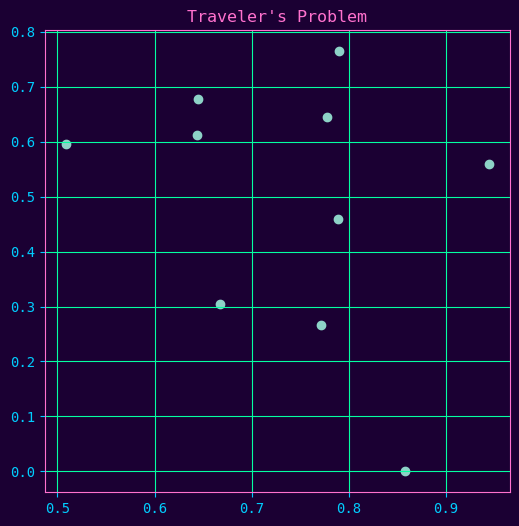

In [18]:
x_coordinates, y_coordinates, distances = generate_tsp_problem(10)
plot_tsp_problem(x_coordinates,y_coordinates)

# Exact resolution of the problem
To solve the problem via the exact resolution, a function will be created that, when given the previously generated matrix of distances, calculates the distance of every possible order of visited cities, comparing which one has the shortest possible route. The function returns the total distance as well as the optimal trayectory.

One key detail when developing this function is the fact that every route will appear twice if every combination of cities is permutated through, as it is not relevant for the final result the direction in which it is transitioned. It must also be mentioned that, to reduce the complexity of the calculation, the starting city will be fixed in every case. It must also be mentioned that, to reduce the complexity of the calculation, the starting city will be fixed in every case.

2.024706615638708


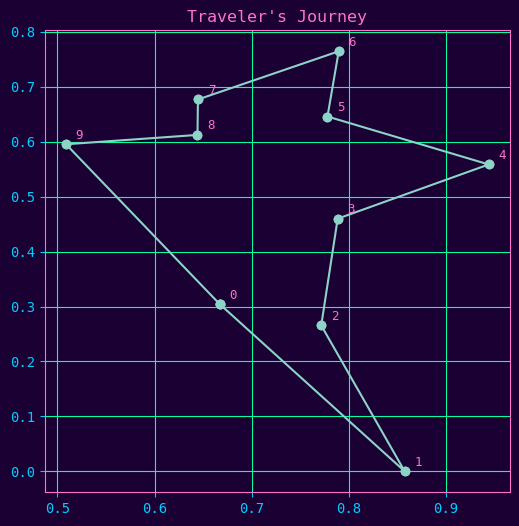

In [19]:
def evaluate_exact_solution(distances: list[list[float]])->tuple[float, list[int]]:
    total_distance = len(distances)*2
    all_routes = list(permutations(range(1, len(distances))))
    for i in range(len(all_routes)): all_routes[i] = list(all_routes[i]) + [0]
    for route in all_routes:
        sum_of_distances = 0
        i = 0
        for j in route:
            sum_of_distances = sum_of_distances + distances[i][j]
            i = j
        if total_distance > sum_of_distances:
            total_distance = sum_of_distances
            best_route = [0] + route
    return total_distance, best_route

exact_total_distance, exact_best_route = evaluate_exact_solution(distances)
print(exact_total_distance)
plot_tsp_problem(x_coordinates,y_coordinates,exact_best_route)

# Closest Neighbour Algorithm
The approximate solution we will focus on to solve the TSP will be the Closest Neighbout Algorithm. The function that will apply this algorithm will be provided of the distances matrix to then check which is the closest city is to the randomly selected first city. It will then repeat this dynamic with each of the selected cities, excluding those that have already been "visited". This function returns the same information as the exact solution one.

In this case, all of the cities will be evaluated as an starting city, as the closest city will be different in all of the different cases.

2.1460281094705405


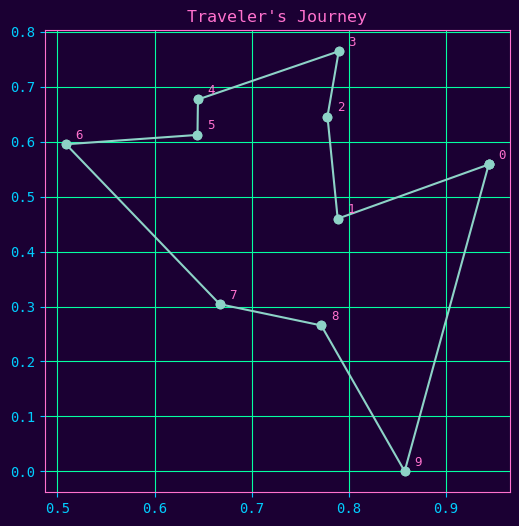

In [20]:
def closest_neighbour(distances):
    best_route = []
    for initial_city in range(len(distances)):
        total_distance = len(distances) * 12
        current_city = initial_city
        total_distance_try = 0
        exclude = [initial_city]
        for i in range(len(distances)-1):
            excluding_filter = [distances[current_city][j] for j in exclude]
            total_distance_try = total_distance_try + min(x for x in distances[current_city] if x not in excluding_filter)
            current_city = distances[current_city].index(min(x for x in distances[current_city] if x not in excluding_filter))
            exclude.append(current_city)
        total_distance_try = total_distance_try + distances[initial_city][current_city]

        if total_distance > total_distance_try:
            total_distance = total_distance_try
            best_route = exclude + [initial_city]
    return total_distance, best_route

total_distance_closest, best_route_closest = closest_neighbour(distances)
print(total_distance_closest)
plot_tsp_problem(x_coordinates,y_coordinates,best_route_closest)

After running tests with 5 to 13 cities (as shown in the table) it can be concluded that the exact method can outperform the Closest Neighbour Algorithm in time and quality of response as long as the number of cities is lower than 10. From 10 onwards, the exact solution starts taking more time to compute, reaching its error at 13 cities, while the Closest Neighbour Algorith stays faster but less effective.

|  Number of cities  |   Time for exact solution (s) ($\pm0.1$)   |  Time for approximate solution (s) ($\pm0.1$)  |
|:------------------:|:------------------------------------------:|:----------------------------------------------:|
|          5         |                     0.0                    |                       0.0                      |
|          6         |                     0.0                    |                       0.0                      |
|          7         |                     0.0                    |                       0.0                      |
|          8         |                     0.0                    |                       0.0                      |
|          9         |                     0.0                    |                       0.0                      |
|         10         |                     0.2                    |                       0.0                      |
|         11         |                     2.5                    |                       0.0                      |
|         12         |                    41.0                    |                       0.0                      |
|         13         |                    Error                   |                       0.0                      |